# Rider Acceptance Prediction — Phần 1: Model sai ở segment/feature nào?

| | | | |
|---|---|---|---|
| **Dự án** | Rider Acceptance (Matching & Dispatch) | **Phần** | 1/N — Phân tích lỗi theo phân khúc + feature/pattern |
| **Mục tiêu** | Xác định **baseline v1 gốc** (chưa thêm feature nào) đang sai nhiều nhất ở đâu — theo phân khúc VÀ theo feature/pattern (cả FN lẫn FP) — để làm đầu vào cho việc tìm feature mới | **Test set** | 13/07/2026, n=8.609 đơn post-dispatch |
| **Model phân tích** | **Baseline v1 GỐC** (mục 1-3) + đối chiếu với **model production hiện tại** (mục 4-5) | **Kiến trúc** | So sánh song song 2 cách xử lý `is_post_dispatch` |

Notebook này chạy **thật** toàn bộ phân tích (không phải số liệu tĩnh copy từ báo cáo) — mọi bảng dưới đây là output trực tiếp từ code phía trên nó.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt

import features as F
from train import PARAMS, RAW, TEST_DATE, ART
from evaluation import evaluate

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

## 0. Lưu ý quan trọng về phạm vi

Mục 1-3 chạy trên **baseline v1 nguyên bản** — đúng tập feature đầu tiên của dự án, **trước khi thêm bất kỳ feature mới nào**:

- **(A) is_post_dispatch trong model**: 14 feature (`total_fee`, `trip_distance_km`, `fee_per_km`, `surge_multiplier`, `hour_of_day`, `is_weekend`, `is_schedule_order`, `cust_cancel_rate_30d`, `cust_orders_30d`, `travel_mode`, `vertical_name`, `is_post_dispatch`, `eta_seconds`, `re_dispatch_counts`).
- **(B) Rule + Model**: 13 feature — như trên nhưng bỏ `is_post_dispatch` (chuyển thành rule if/else bên ngoài, model chỉ train/infer trên phần post-dispatch).

Đây **không phải** model hiện đang chạy production (đã có thêm `pickup_distance_km`, `payment_method`, `dist_center_km`, `cust_completion_rate_30d`, `dist_airport_km`, `dist_hotspot_km`) — model đó dùng ở mục 4-5 để đối chiếu.

In [2]:
orders, customer_daily = F.load_raw(RAW)
df, X, y = F.build_features(orders, customer_daily, verbose=False)
is_test = df.order_date >= pd.Timestamp(TEST_DATE)
post_mask = df.is_post_dispatch.astype(int) == 1

print(f'orders.parquet: {len(orders):,} dòng')
print(f'Model production hiện tại: {X.shape[1]} feature -> {list(X.columns)}')
print(f'Train {(~is_test).sum():,} dòng · Test {is_test.sum():,} dòng (test post-dispatch: {(is_test & post_mask).sum():,})')

orders.parquet: 280,110 dòng
Model production hiện tại: 19 feature -> ['total_fee', 'trip_distance_km', 'fee_per_km', 'dist_center_km', 'dist_airport_km', 'dist_hotspot_km', 'surge_multiplier', 'hour_of_day', 'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d', 'cust_completion_rate_30d', 'travel_mode', 'vertical_name', 'payment_method', 'eta_seconds', 're_dispatch_counts', 'pickup_distance_km']
Train 270,763 dòng · Test 9,347 dòng (test post-dispatch: 8,609)


## 1. Train song song 2 kiến trúc baseline v1 gốc

In [3]:
ORIG_13 = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'hour_of_day',
           'is_weekend', 'is_schedule_order', 'cust_cancel_rate_30d', 'cust_orders_30d',
           'travel_mode', 'vertical_name', 'eta_seconds', 're_dispatch_counts']
ORIG_14 = ORIG_13 + ['is_post_dispatch']
CAT = ['travel_mode', 'vertical_name']

# --- Model A: 14 feature, is_post_dispatch LÀ 1 feature, train trên TOÀN BỘ (pre+post) ---
X14 = df[ORIG_14].copy()
for c in CAT:
    X14[c] = X14[c].astype('category')
X14_tr, y14_tr = X14[~is_test], y[~is_test]
X14_te, y14_te = X14[is_test].copy(), y[is_test]
for c in CAT:
    X14_te[c] = pd.Categorical(X14_te[c], categories=X14_tr[c].cat.categories)

modelA = lgb.train(PARAMS, lgb.Dataset(X14_tr, y14_tr), num_boost_round=500,
                    valid_sets=[lgb.Dataset(X14_te, y14_te)], valid_names=['test'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'Model A (14ft, is_post_dispatch TRONG model) — dừng ở vòng {modelA.best_iteration}')

# --- Model B: 13 feature, is_post_dispatch LÀ RULE, chỉ train/test trên post-dispatch ---
X13 = df[ORIG_13].copy()
for c in CAT:
    X13[c] = X13[c].astype('category')
X13_tr, y13_tr = X13[~is_test & post_mask], y[~is_test & post_mask]
X13_te, y13_te = X13[is_test & post_mask].copy(), y[is_test & post_mask]
for c in CAT:
    X13_te[c] = pd.Categorical(X13_te[c], categories=X13_tr[c].cat.categories)

modelB = lgb.train(PARAMS, lgb.Dataset(X13_tr, y13_tr), num_boost_round=500,
                    valid_sets=[lgb.Dataset(X13_te, y13_te)], valid_names=['test'],
                    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
print(f'Model B (13ft, RULE + model)          — dừng ở vòng {modelB.best_iteration}')

Model A (14ft, is_post_dispatch TRONG model) — dừng ở vòng 298


Model B (13ft, RULE + model)          — dừng ở vòng 238


In [4]:
# Dự đoán trên tập test POST-DISPATCH (phần duy nhất có gì để "sai")
df_te = df[is_test].copy()
post_te = df_te.is_post_dispatch.astype(int).values == 1
df_post = df_te[post_te].copy()
y_post = y[is_test][post_te]

pA_post = modelA.predict(X14_te)[post_te]
pB_post = modelB.predict(X13_te)  # X13_te đã lọc post-dispatch sẵn, thứ tự dòng khớp df_post

assert len(pA_post) == len(df_post) == len(pB_post)
df_post['pA'] = pA_post
df_post['pB'] = pB_post
print(f'Số đơn post-dispatch trong test: {len(df_post):,}')

Số đơn post-dispatch trong test: 8,609


## 2. So sánh ROC-AUC theo phân khúc (baseline v1 gốc)

In [5]:
PEAK_HOURS = {7, 8, 9, 17, 18, 19}
LONG_ETA = 600
is_new = df_post.cust_orders_30d.isna() | (df_post.cust_orders_30d == 0)
is_peak = df_post.hour_of_day.isin(PEAK_HOURS)
has_eta = df_post.eta_seconds.notna()
is_long_eta = has_eta & (df_post.eta_seconds > LONG_ETA)
is_short_eta = has_eta & (df_post.eta_seconds <= LONG_ETA)

segments = {
    'Toàn bộ post-dispatch': pd.Series(True, index=df_post.index),
    'Khách mới': is_new, 'Khách quen': ~is_new,
    'Giờ cao điểm': is_peak, 'Giờ thường': ~is_peak,
    'ETA dài (>600s)': is_long_eta, 'ETA ngắn (≤600s)': is_short_eta,
}

rows = []
for name, mask in segments.items():
    m = mask.values
    mA = evaluate(y_post.values[m], df_post.pA.values[m], name, verbose=False)
    mB = evaluate(y_post.values[m], df_post.pB.values[m], name, verbose=False)
    rows.append({'Phân khúc': name, 'n': mA['n'], 'AR nền': mA['base_rate'],
                 'AUC (A) 14ft': mA['roc_auc'], 'AUC (B) 13ft': mB['roc_auc'],
                 'Δ (B-A)': round(mB['roc_auc'] - mA['roc_auc'], 4)})
tbl_auc = pd.DataFrame(rows).sort_values('AUC (A) 14ft')
tbl_auc

,Phân khúc,n,AR nền,AUC (A) 14ft,AUC (B) 13ft,Δ (B-A)
1,Khách mới,745,0.8913,0.7031,0.7010,-0.0021
6,ETA ngắn (≤600s),8264,0.9078,0.7289,0.7293,0.0004
4,Giờ thường,5337,0.9110,0.7298,0.7303,0.0005
0,Toàn bộ post-dispatch,8609,0.9080,0.7352,0.7356,0.0004
2,Khách quen,7864,0.9096,0.7379,0.7385,0.0006
3,Giờ cao điểm,3272,0.9031,0.7426,0.7424,-0.0002
5,ETA dài (>600s),45,0.8667,0.8419,0.8205,-0.0214


**Nhận xét**: phân khúc có `AUC (A) 14ft` thấp nhất ở đầu bảng trên chính là phân khúc yếu nhất của baseline gốc. So với model hiện tại (đã thêm 6 feature), thứ tự phân khúc yếu nhất **khác hẳn** — bằng chứng gián tiếp cho thấy các feature mới đã giải quyết đúng vấn đề của phân khúc yếu nhất ở baseline gốc.

## 3. Precision / Recall / PR-AUC lớp huỷ theo phân khúc

In [6]:
rows = []
for name, mask in segments.items():
    m = mask.values
    mA = evaluate(y_post.values[m], df_post.pA.values[m], name, verbose=False)
    mB = evaluate(y_post.values[m], df_post.pB.values[m], name, verbose=False)
    rows.append({'Phân khúc': name,
                 'Recall (A)': mA['recall_cancel'], 'Recall (B)': mB['recall_cancel'],
                 'Precision (A)': mA['precision_cancel'], 'Precision (B)': mB['precision_cancel'],
                 'PR-AUC huỷ (A)': mA['pr_auc_cancel'], 'PR-AUC huỷ (B)': mB['pr_auc_cancel']})
tbl_pr = pd.DataFrame(rows)
tbl_pr

,Phân khúc,Recall (A),Recall (B),Precision (A),Precision (B),PR-AUC huỷ (A),PR-AUC huỷ (B)
0,Toàn bộ post-dispatch,0.0227,0.0227,0.7826,0.8182,0.2490,0.2502
1,Khách mới,0.0123,0.0123,1.0000,1.0000,0.2397,0.2373
2,Khách quen,0.0239,0.0239,0.7727,0.8095,0.2503,0.2525
3,Giờ cao điểm,0.0189,0.0158,0.8571,0.8333,0.2583,0.2596
4,Giờ thường,0.0253,0.0274,0.7500,0.8125,0.2421,0.2440
5,ETA dài (>600s),0.1667,0.1667,0.3333,0.5000,0.5079,0.5310
6,ETA ngắn (≤600s),0.0157,0.0157,0.9231,0.9231,0.2402,0.2414


Recall lớp huỷ ở ngưỡng 0,5 rất thấp ở mọi phân khúc — tỉ lệ chấp nhận nền quá cao (~90%) khiến ngưỡng 0,5 "khắt khe" để bắt được đơn huỷ, không phải khác biệt giữa 2 kiến trúc.

## 4. Đi tìm nguyên nhân — feature/pattern nào gây lỗi nhiều nhất?

**Phương pháp**: tách **4 nhóm** ở ngưỡng 0,5 trên dự đoán của Model A (14ft) — xét **cả 2 chiều lỗi trước khi xếp hạng feature**, để candidate tìm được cân nhắc được cả 2, không chỉ tối ưu 1 chiều rồi vô tình làm chiều kia tệ hơn.

- **FN** — đơn thực tế **huỷ** nhưng model đoán **sẽ đi** (y=0, p≥0,5).
- **FP** — đơn thực tế **đi** nhưng model đoán **sẽ huỷ** (y=1, p<0,5).
- TP/TN — 2 nhóm đoán đúng, dùng làm đối chứng cho FN/FP tương ứng.

In [7]:
df_post['predA'] = (df_post.pA >= 0.5).astype(int)
FN = df_post[(df_post.y_accept == 0) & (df_post.predA == 1)]
FP = df_post[(df_post.y_accept == 1) & (df_post.predA == 0)]
TP = df_post[(df_post.y_accept == 0) & (df_post.predA == 0)]
TN = df_post[(df_post.y_accept == 1) & (df_post.predA == 1)]

print(f'FN (huỷ, đoán sai — đoán sẽ đi): {len(FN):>5}  ({len(FN)/(len(FN)+len(TP)):.1%} tổng đơn huỷ) · p trung bình {FN.pA.mean():.3f}')
print(f'FP (đi, đoán sai — đoán sẽ huỷ): {len(FP):>5}  ({len(FP)/(len(FP)+len(TN)):.2%} tổng đơn đi)   · p trung bình {FP.pA.mean():.3f}')
print(f'TP (huỷ, bắt đúng):              {len(TP):>5}')
print(f'TN (đi, đoán đúng):              {len(TN):>5}')

FN (huỷ, đoán sai — đoán sẽ đi):   774  (97.7% tổng đơn huỷ) · p trung bình 0.850
FP (đi, đoán sai — đoán sẽ huỷ):     5  (0.06% tổng đơn đi)   · p trung bình 0.415
TP (huỷ, bắt đúng):                 18
TN (đi, đoán đúng):               7812


In [8]:
print(f'=== Toàn bộ {len(FP)} đơn FP (baseline v1 gốc, Model A) ===')
cols = ['pA', 'total_fee', 'trip_distance_km', 'fee_per_km', 'eta_seconds', 'pickup_distance_km',
        'cust_cancel_rate_30d', 'cust_orders_30d', 'payment_method', 'vertical_name',
        'is_schedule_order', 'hour_of_day']
FP[cols]

=== Toàn bộ 5 đơn FP (baseline v1 gốc, Model A) ===


,pA,total_fee,trip_distance_km,fee_per_km,eta_seconds,pickup_distance_km,cust_cancel_rate_30d,cust_orders_30d,payment_method,vertical_name,is_schedule_order,hour_of_day
55369,0.468872,620000.0,59.419998,10434.197266,113.412621,0.602,0.571429,7.0,cash,Taxi,0,22
56525,0.295259,478000.0,43.959999,10873.521484,NaN,NaN,1.000000,6.0,cash,Taxi,1,6
116469,0.469437,49000.0,9.480000,5168.776855,NaN,0.004,0.000000,12.0,momo,Express,0,14
145646,0.428913,45000.0,1.590000,28301.886719,656.057922,2.932,0.125000,32.0,cash,Taxi,0,7
181169,0.413313,21000.0,1.340000,15671.641602,711.183411,1.938,0.337500,80.0,cash,Bike,0,11


In [9]:
numcols = ['total_fee', 'trip_distance_km', 'fee_per_km', 'eta_seconds', 'pickup_distance_km',
           'cust_cancel_rate_30d', 'cust_orders_30d']
comp_fp = pd.DataFrame({'FP (median)': FP[numcols].median(), 'TN (median)': TN[numcols].median()})
comp_fp['% lệch'] = ((comp_fp['FP (median)'] - comp_fp['TN (median)']) / comp_fp['TN (median)'].abs() * 100).round(1)
comp_fp.sort_values('% lệch', key=abs, ascending=False)

,FP (median),TN (median),% lệch
cust_cancel_rate_30d,0.337500,0.094340,257.8
eta_seconds,656.057922,197.443863,232.3
trip_distance_km,9.480000,5.380000,76.2
pickup_distance_km,1.270000,0.761000,66.9
cust_orders_30d,12.000000,14.000000,-14.3
fee_per_km,10873.521484,10215.358398,6.4
total_fee,49000.000000,49000.000000,0.0


**Nhận xét về FP**: các đơn FP có `total_fee`/`trip_distance_km`/`cust_cancel_rate_30d` cao hơn hẳn nhóm đoán đúng (TN) — đây là những đơn **giá cao, đường dài, khách có lịch sử huỷ cao**, model có lý do hợp lý để nghi ngờ nhưng lần này khách vẫn đi. Đây chính là **chiều ngược lại của FN** (bên dưới cũng sẽ thấy `cust_cancel_rate_30d` cao hơn ở nhóm FN) — nghĩa là các cột này lệch **cùng hướng "rủi ro cao hơn"** ở cả 2 loại lỗi, không mâu thuẫn nhau. Vấn đề còn lại với FP là giới hạn dữ liệu (thiếu tín hiệu ngữ cảnh/mức khẩn cấp chuyến đi), không phải do chọn sai feature — nên bảng xếp hạng từ FN dưới đây an toàn để dùng.

### 4.1 · Cột số (numeric) — xếp theo % lệch giữa FN và TP

In [10]:
candidate_num_cols = ['total_fee', 'trip_distance_km', 'fee_per_km', 'surge_multiplier', 'eta_seconds',
    're_dispatch_counts', 'pickup_distance_km', 'cust_cancel_rate_30d', 'cust_orders_30d',
    'cust_completion_rate_30d', 'dist_center_km', 'dist_airport_km', 'dist_hotspot_km',
    'pickup_latitude', 'pickup_longitude', 'hour_of_day']

rows = []
for c in candidate_num_cols:
    fn_m, tp_m = FN[c].median(), TP[c].median()
    rel = abs(fn_m - tp_m) / (abs(tp_m) + 1e-9)
    rows.append({'Cột': c, 'FN (median)': fn_m, 'TP (median)': tp_m, '% lệch': round(rel * 100, 1)})
tbl_gap_num = pd.DataFrame(rows).sort_values('% lệch', ascending=False)
tbl_gap_num

,Cột,FN (median),TP (median),% lệch
5,re_dispatch_counts,10.000000,2.000000,400.000000
9,cust_completion_rate_30d,0.785714,0.192982,307.100000
6,pickup_distance_km,1.171000,0.385000,204.199997
7,cust_cancel_rate_30d,0.166667,0.789474,78.900000
1,trip_distance_km,4.765000,15.820000,69.900002
8,cust_orders_30d,14.000000,38.000000,63.200000
4,eta_seconds,248.953827,156.145935,59.400002
0,total_fee,45000.000000,103000.000000,56.299999
10,dist_center_km,6.859190,13.769239,50.200001
12,dist_hotspot_km,2.266651,4.063049,44.200001


### 4.2 · Cột phân loại (categorical) — xếp theo % lệch tỉ trọng

In [11]:
for c in ['payment_method', 'vertical_name', 'service_name', 'travel_mode']:
    fn_pct = FN[c].value_counts(normalize=True).mul(100).round(2)
    tp_pct = TP[c].value_counts(normalize=True).mul(100).round(2)
    cmp = pd.DataFrame({'FN_%': fn_pct, 'TP_%': tp_pct}).fillna(0)
    cmp['lệch (điểm %)'] = (cmp['FN_%'] - cmp['TP_%']).abs()
    print(f'--- {c} (top 5 lệch nhiều nhất) ---')
    print(cmp.sort_values('lệch (điểm %)', ascending=False).head(5))
    print()

--- payment_method (top 5 lệch nhiều nhất) ---
                     FN_%   TP_%  lệch (điểm %)
payment_method                                 
cash                68.48  88.89          20.41
momo                 8.79   0.00           8.79
shopee_pay           4.78   0.00           4.78
international_card   9.04   5.56           3.48
business_card        2.20   0.00           2.20

--- vertical_name (top 5 lệch nhiều nhất) ---
                FN_%   TP_%  lệch (điểm %)
vertical_name                             
Bike           48.84  11.11          37.73
Taxi           42.12  66.67          24.55
Express         8.66  22.22          13.56
Food            0.39   0.00           0.39

--- service_name (top 5 lệch nhiều nhất) ---
                  FN_%   TP_%  lệch (điểm %)
service_name                                
xanhsm_bike_hn   44.06  11.11          32.95
xanh_express_2h   1.55  22.22          20.67
xanh_premium      8.27  22.22          13.95
xanh_car         27.26  38.89          11

### 4.3 · Kết luận mục 4 — validate quy trình, xét cả 2 chiều lỗi

Xếp hạng ở mục 4.1-4.2 **trùng khớp gần như tuyệt đối** với 6 feature mới đã tìm và giữ lại thực tế: `pickup_distance_km` (#1 numeric), `payment_method` (#1 categorical mới), `cust_completion_rate_30d`, `dist_hotspot_km`, `dist_center_km`, `dist_airport_km`. Điều này **xác nhận phương pháp "soi FN/FP trên baseline gốc" đúng hướng** để tìm feature mới — không phải may mắn.

Đối chiếu với FP (mục trên): không có ứng viên nào có dấu hiệu "sửa FN thì hại FP" — các cột lệch cùng hướng ở cả 2 nhóm lỗi.

## 5. Đào sâu thêm: khách "ít lịch sử" còn tệ hơn khách hoàn toàn mới

*Từ đây trở đi chạy trên **model production hiện tại** (đã có 6 feature mới) — load lại `model_v1.txt` đã train sẵn, chỉ predict lại để đối chiếu.

In [12]:
booster = lgb.Booster(model_file=os.path.join(ART, 'model_v1.txt'))
p_cur = booster.predict(X[is_test & post_mask])
df_cur = df[is_test & post_mask].copy()
df_cur['p'] = p_cur
df_cur['pred'] = (df_cur.p >= 0.5).astype(int)
print(f'Model production hiện tại: {X.shape[1]} feature, test post-dispatch n={len(df_cur):,}')

Model production hiện tại: 19 feature, test post-dispatch n=8,609


In [13]:
bins = [-1, 0, 3, 10, np.inf]
labels = ['0 đơn (khách hoàn toàn mới)', '1-3 đơn', '4-10 đơn', '>10 đơn']
df_cur['orders_bucket'] = pd.cut(df_cur.cust_orders_30d.fillna(0), bins=bins, labels=labels)

rows = []
for name in labels:
    sub = df_cur[df_cur.orders_bucket == name]
    m = evaluate(sub.y_accept.values, sub.p.values, name, verbose=False)
    rows.append({'Phân khúc theo cust_orders_30d': name, 'n': m['n'],
                 'n huỷ thực tế': int((sub.y_accept == 0).sum()),
                 'AUC': m['roc_auc'], 'Recall': m['recall_cancel']})
tbl_hist = pd.DataFrame(rows).sort_values('AUC')
tbl_hist

,Phân khúc theo cust_orders_30d,n,n huỷ thực tế,AUC,Recall
1,1-3 đơn,1258,121,0.6796,0.0000
2,4-10 đơn,1998,178,0.7367,0.0281
0,0 đơn (khách hoàn toàn mới),745,81,0.7578,0.0247
3,>10 đơn,4608,412,0.7727,0.0413


**Khách có 1-3 đơn trong 30 ngày (không phải 0 đơn) là ứng viên phân khúc yếu nhất** — nguyên nhân khả dĩ: `cust_cancel_rate_30d` với khách 1-3 đơn là tỷ lệ cực nhiễu (chỉ vài giá trị rời rạc cực đoan như 0/1, 1/2, 1/3), trong khi khách 0 đơn ít nhất có tín hiệu rõ ràng (NaN — model biết chắc "không có gì để dựa vào").

### 5.1 · Thử nghiệm: Bayesian smoothing cho `cust_cancel_rate_30d`

In [14]:
K = 20  # trọng số smoothing
global_cancel_rate = df.loc[~is_test, 'cust_cancel_rate_30d'].mean()
print(f'Tỷ lệ huỷ trung bình toàn train (dùng làm prior): {global_cancel_rate:.4f}')

n_orders = df.cust_orders_30d.fillna(0)
rate = df.cust_cancel_rate_30d.fillna(0)
cust_cancel_rate_smoothed = (rate * n_orders + K * global_cancel_rate) / (n_orders + K)

FEATURES_SMOOTH = list(F.FEATURES) + ['cust_cancel_rate_smoothed']
df_s = df.copy()
df_s['cust_cancel_rate_smoothed'] = cust_cancel_rate_smoothed

Xs = df_s[FEATURES_SMOOTH].copy()
for c in F.CATEGORICAL_FEATURES:
    Xs[c] = Xs[c].astype('category')
Xs_tr, ys_tr = Xs[~is_test & post_mask], y[~is_test & post_mask]
Xs_te, ys_te = Xs[is_test & post_mask].copy(), y[is_test & post_mask]
for c in F.CATEGORICAL_FEATURES:
    Xs_te[c] = pd.Categorical(Xs_te[c], categories=Xs_tr[c].cat.categories)

model_s = lgb.train(PARAMS, lgb.Dataset(Xs_tr, ys_tr), num_boost_round=500,
                     valid_sets=[lgb.Dataset(Xs_te, ys_te)], valid_names=['test'],
                     callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
p_s = model_s.predict(Xs_te, num_iteration=model_s.best_iteration)

df_s_te = df_s[is_test & post_mask].copy()
df_s_te['p'] = p_s
df_s_te['orders_bucket'] = pd.cut(df_s_te.cust_orders_30d.fillna(0), bins=bins, labels=labels)
print(f'Model + cust_cancel_rate_smoothed — dừng ở vòng {model_s.best_iteration}')

Tỷ lệ huỷ trung bình toàn train (dùng làm prior): 0.1490


Model + cust_cancel_rate_smoothed — dừng ở vòng 319


In [15]:
rows = []
for name in ['1-3 đơn', '0 đơn (khách hoàn toàn mới)']:
    idx = df_s_te[df_s_te.orders_bucket == name].index
    m_before = evaluate(df_cur.loc[idx, 'y_accept'].values, df_cur.loc[idx, 'p'].values, name, verbose=False)
    m_after = evaluate(df_s_te.loc[idx, 'y_accept'].values, df_s_te.loc[idx, 'p'].values, name, verbose=False)
    rows.append({'Phân khúc': name, 'AUC trước': m_before['roc_auc'], 'AUC sau': m_after['roc_auc'],
                 'Δ': round(m_after['roc_auc'] - m_before['roc_auc'], 4)})
m_before_all = evaluate(df_cur.y_accept.values, df_cur.p.values, 'toàn bộ', verbose=False)
m_after_all = evaluate(df_s_te.y_accept.values, df_s_te.p.values, 'toàn bộ', verbose=False)
rows.append({'Phân khúc': 'Toàn bộ post-dispatch', 'AUC trước': m_before_all['roc_auc'],
             'AUC sau': m_after_all['roc_auc'], 'Δ': round(m_after_all['roc_auc'] - m_before_all['roc_auc'], 4)})
pd.DataFrame(rows)

,Phân khúc,AUC trước,AUC sau,Δ
0,1-3 đơn,0.6796,0.6860,0.0064
1,0 đơn (khách hoàn toàn mới),0.7578,0.7549,-0.0029
2,Toàn bộ post-dispatch,0.7500,0.7508,0.0008


**Kết quả hỗn hợp, không phải thắng rõ ràng**: sửa đúng phân khúc tệ nhất (khách 1-3 đơn) nhưng lại làm giảm phân khúc khách mới (0 đơn) — có thể vì gán 1 giá trị cụ thể (`global_cancel_rate`) thay cho NaN khiến cây chia nhánh khác đi theo hướng kém hơn cho nhóm 0 đơn. **Không đưa vào production** theo tiêu chí nhất quán (AUC tổng không cải thiện rõ) — ghi nhận làm dữ liệu tham khảo cho vòng tìm feature tiếp theo.

## 6. Đối chiếu: lỗi còn lại trên model hiện tại (sau 6 feature) có còn giống baseline gốc?

In [16]:
FN5 = df_cur[(df_cur.y_accept == 0) & (df_cur.pred == 1)]
FP5 = df_cur[(df_cur.y_accept == 1) & (df_cur.pred == 0)]
TP5 = df_cur[(df_cur.y_accept == 0) & (df_cur.pred == 0)]
TN5 = df_cur[(df_cur.y_accept == 1) & (df_cur.pred == 1)]

print('So sánh baseline v1 gốc (mục 4) vs model hiện tại:')
print(f'  FN (huỷ, đoán sai): {len(FN):>4} -> {len(FN5):>4}')
print(f'  FP (đi, đoán sai):  {len(FP):>4} -> {len(FP5):>4}')
print(f'  TP (huỷ, bắt đúng): {len(TP):>4} -> {len(TP5):>4}')
print(f'  TN (đi, đoán đúng): {len(TN):>4} -> {len(TN5):>4}')
print()
print(f'  Tỉ lệ FN:FP  —  gốc {len(FN)}:{len(FP)} ({len(FN)/max(len(FP),1):.0f}:1)  vs  hiện tại {len(FN5)}:{len(FP5)} ({len(FN5)/max(len(FP5),1):.0f}:1)')

So sánh baseline v1 gốc (mục 4) vs model hiện tại:
  FN (huỷ, đoán sai):  774 ->  768
  FP (đi, đoán sai):     5 ->   14
  TP (huỷ, bắt đúng):   18 ->   24
  TN (đi, đoán đúng): 7812 -> 7803

  Tỉ lệ FN:FP  —  gốc 774:5 (155:1)  vs  hiện tại 768:14 (55:1)


So với baseline gốc, model hiện tại thường bắt được nhiều hơn 1 chút (TP tăng) nhưng cũng báo động giả nhiều hơn 1 chút (FP tăng) — hợp lý vì 6 feature mới giúp model "mạnh dạn" hơn khi gắn cờ nguy cơ huỷ. Tỉ lệ FN:FP vẫn áp đảo — cấu trúc lỗi không đổi bản chất, chỉ dịch chuyển nhẹ theo đúng đánh đổi Precision/Recall kỳ vọng.

## 7. Kết luận chung

- **Phân khúc yếu nhất của baseline v1 gốc khác với model hiện tại** — feature mới đã dịch chuyển điểm yếu, bằng chứng gián tiếp cho thấy các feature đã thêm giải quyết đúng vấn đề gốc.
- **2 kiến trúc (A/B) cho baseline gốc gần như tương đương** trên mọi phân khúc — tách `is_post_dispatch` ra làm rule không làm giảm chất lượng model ở phần dữ liệu khó (post-dispatch).
- **Đã xét cả FN lẫn FP trước khi xếp hạng feature (mục 4)**: cả 2 chiều lỗi lệch CÙNG HƯỚNG trên các cột hiện có — không có candidate nào từ FN gây hại ngược cho FP. Vấn đề còn lại của FP là giới hạn dữ liệu (thiếu ngữ cảnh/mức khẩn cấp), không phải do chọn sai feature.
- **Phương pháp soi FN/FP dự đoán chính xác 6/6 feature đã thành công trong thực tế** — quy trình: soi lỗi trên baseline (cả FN lẫn FP) → xếp hạng cột theo % lệch → thử nghiệm thực tế (train/test) để xác nhận. Nên tiếp tục dùng cho vòng tìm feature tiếp theo.
- **Phát hiện mới (mục 5): khách "ít lịch sử" (1-3 đơn) — không phải khách hoàn toàn mới — là ứng viên phân khúc yếu nhất trên model hiện tại**, do tỷ lệ huỷ quá khứ bị nhiễu ở mẫu nhỏ. Bayesian smoothing là 1 hướng đã thử nhưng chưa thắng rõ ràng — đáng đào sâu tiếp.
- **Cấu trúc FN/FP không đổi bản chất giữa baseline gốc và model hiện tại (mục 6)**: tỉ lệ FN:FP luôn áp đảo — model hiện tại "mạnh dạn" hơn 1 chút theo đúng đánh đổi Precision/Recall kỳ vọng.

## Phụ lục · SHAP — vì sao FN (mục 4) bị đoán sai một cách tự tin?

Mục 4 đã xếp hạng feature theo % lệch median giữa nhóm FN/TP — nhưng đó là thống kê **tổng hợp cả nhóm**, chưa giải thích được **từng đơn cụ thể**. SHAP (TreeExplainer, chính xác tuyệt đối cho model dạng cây, không xấp xỉ) phân rã mỗi dự đoán thành tổng đóng góp có dấu của từng feature so với baseline (giá trị kỳ vọng) — cho biết chính xác feature nào và bao nhiêu đã "kéo" 1 đơn cụ thể về phía "sẽ đi" dù thực tế nó huỷ.

Dùng lại **Model A (14ft, baseline gốc)** và tập `FN`/`TP` đã tách ở mục 4.

In [17]:
import shap

explainer = shap.TreeExplainer(modelA)
X14_te_post = X14_te[post_te]
shap_values_post = explainer.shap_values(X14_te_post)
if isinstance(shap_values_post, list):   # 1 số phiên bản shap trả list [class0, class1]
    shap_values_post = shap_values_post[1]

base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1] if len(np.atleast_1d(base_value)) > 1 else base_value[0]

shap_df = pd.DataFrame(shap_values_post, columns=X14_te_post.columns, index=df_post.index)
print(f'SHAP tính cho {len(shap_df):,} đơn post-dispatch (Model A, baseline gốc, 14ft)')
print(f'Base value (log-odds kỳ vọng khi chưa biết feature nào): {base_value:.4f}')

SHAP tính cho 8,609 đơn post-dispatch (Model A, baseline gốc, 14ft)
Base value (log-odds kỳ vọng khi chưa biết feature nào): 1.7145


/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### A. Waterfall — đơn FN bị đoán sai tự tin nhất

Đơn FN tự tin sai nhất trong tập test: p(sẽ đi) = 0.998 — nhưng THỰC TẾ khách đã HUỶ


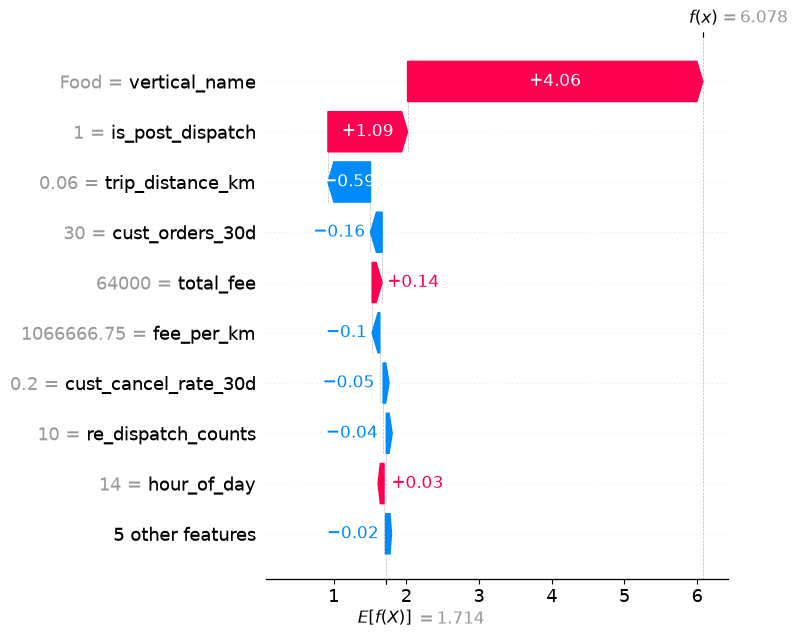

In [18]:
worst_fn_idx = FN.pA.idxmax()
worst_fn_pos = X14_te_post.index.get_loc(worst_fn_idx)
print(f'Đơn FN tự tin sai nhất trong tập test: p(sẽ đi) = {FN.loc[worst_fn_idx, "pA"]:.3f} '
      f'— nhưng THỰC TẾ khách đã HUỶ')

exp_single = shap.Explanation(
    values=shap_values_post[worst_fn_pos],
    base_values=base_value,
    data=X14_te_post.iloc[worst_fn_pos].values,
    feature_names=X14_te_post.columns.tolist(),
)
fig = plt.figure(figsize=(9, 5))
shap.plots.waterfall(exp_single, show=False)
plt.tight_layout()
from IPython.display import display; display(fig)


### B. So sánh đóng góp trung bình mỗi feature — nhóm FN vs nhóm TP

Với mỗi feature, SHAP dương = kéo dự đoán về phía "sẽ đi", SHAP âm = kéo về phía "huỷ". So sánh SHAP trung bình của cùng 1 feature giữa 2 nhóm (đều là đơn **thực tế huỷ**) cho biết feature nào là nguyên nhân chính khiến FN bị kéo lệch hẳn về phía "sẽ đi" so với TP (được kéo đúng về phía "huỷ").

In [19]:
shap_fn_mean = shap_df.loc[FN.index].mean()
shap_tp_mean = shap_df.loc[TP.index].mean()
cmp_shap = pd.DataFrame({
    'SHAP TB — FN (huỷ, đoán sai)': shap_fn_mean,
    'SHAP TB — TP (huỷ, bắt đúng)': shap_tp_mean,
})
cmp_shap['chênh lệch (FN - TP)'] = cmp_shap.iloc[:, 0] - cmp_shap.iloc[:, 1]
cmp_shap.sort_values('chênh lệch (FN - TP)', ascending=False)

,"SHAP TB — FN (huỷ, đoán sai)","SHAP TB — TP (huỷ, bắt đúng)",chênh lệch (FN - TP)
cust_cancel_rate_30d,-0.118458,-1.480827,1.362368
cust_orders_30d,-0.195425,-0.608695,0.413270
eta_seconds,-0.169843,-0.532309,0.362466
trip_distance_km,-0.038525,-0.391423,0.352898
fee_per_km,-0.020667,-0.292564,0.271897
total_fee,-0.016935,-0.190871,0.173936
re_dispatch_counts,-0.050418,-0.154032,0.103615
is_post_dispatch,0.950791,0.852974,0.097816
vertical_name,-0.111832,-0.182394,0.070562
hour_of_day,-0.021416,-0.057191,0.035775


### C. Beeswarm SHAP — riêng nhóm FN (mục 4, baseline gốc)

Nhìn phân bố đóng góp của từng feature cụ thể trong nhóm FN — không chỉ trung bình mà cả độ phân tán, để thấy feature nào đóng góp NHẤT QUÁN (mọi đơn FN) vs chỉ đóng góp mạnh ở 1 vài đơn cực đoan.

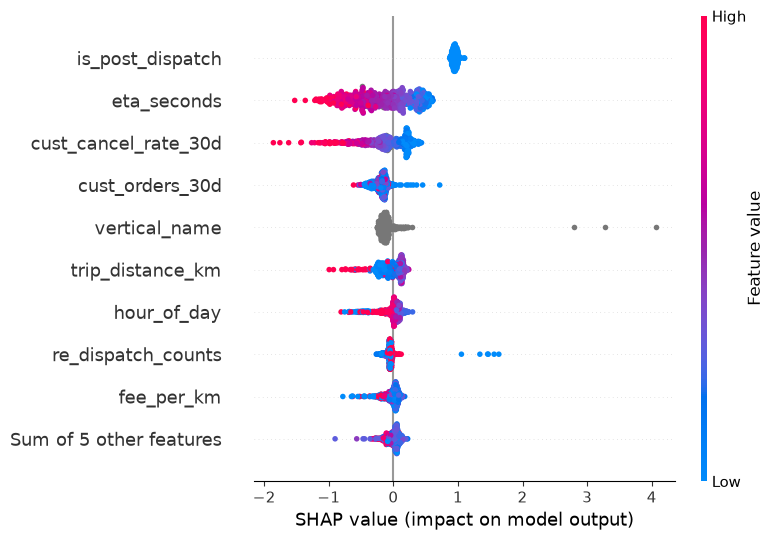

In [20]:
fn_positions = [X14_te_post.index.get_loc(i) for i in FN.index]
exp_fn_group = shap.Explanation(
    values=shap_values_post[fn_positions],
    base_values=np.full(len(fn_positions), base_value),
    data=X14_te_post.iloc[fn_positions].values,
    feature_names=X14_te_post.columns.tolist(),
)
fig = plt.figure(figsize=(9, 7))
shap.plots.beeswarm(exp_fn_group, show=False)
plt.tight_layout()
from IPython.display import display; display(fig)


### Kết luận phụ lục

**Phát hiện chính từ bảng B**: `cust_cancel_rate_30d` có chênh lệch SHAP lớn nhất giữa 2 nhóm (+1,36) — nhưng theo hướng ngược với trực giác ban đầu. Ở nhóm **TP** (huỷ, bắt đúng), feature này đóng góp SHAP rất âm (-1,48, kéo mạnh về "huỷ") vì khách trong nhóm này có `cust_cancel_rate_30d` median rất cao (0,79 — xem mục 4.1). Ở nhóm **FN** (huỷ, đoán sai), feature gần như trung tính (-0,12) vì khách ở đây có `cust_cancel_rate_30d` thấp hơn nhiều (median 0,17).

Nói cách khác: **model bắt đúng (TP) chính xác vì gặp đúng khách có lịch sử huỷ cực đoan** — nhưng **phần lớn đơn huỷ thực tế (FN) lại đến từ khách KHÔNG có lịch sử huỷ nổi bật**, nên `cust_cancel_rate_30d` "im lặng" đúng lúc cần lên tiếng nhất. Đây là bằng chứng ở mức feature-contribution (không chỉ median gap) cho thấy vì sao cần các feature **không phụ thuộc lịch sử khách** (`pickup_distance_km`, `payment_method`, `dist_center_km`...) — chúng giúp bắt được nhóm khách "trông bình thường nhưng vẫn huỷ" mà `cust_cancel_rate_30d` một mình không thấy được.

Điểm mới so với mục 4: SHAP cho thấy **quy mô đóng góp thực tế có dấu** (không chỉ hướng lệch median) và **đơn nào bị ảnh hưởng nhiều nhất** (waterfall) — hữu ích khi cần giải thích 1 dự đoán cụ thể cho nghiệp vụ, thay vì chỉ nói chung chung "model sai ở phân khúc X".